# Flickr30k — BERTopic-Driven Label Generation Pipeline

This notebook replaces the keyword-matching approach with a two-phase pipeline:

1. **Phase 1 — Topic Discovery (BERTopic)**: Run BERTopic on all captions to discover semantic clusters. Topics are inspected and manually merged into meaningful label categories.
2. **Phase 2 — Label Assignment (Zero-shot NLI)**: Use a zero-shot classification model (MNLI) to assign final labels to each image using the category names discovered in Phase 1.

**Why this is stronger than keyword matching:**
- BERTopic finds categories *empirically* from the data — no guessing upfront
- NLI-based assignment understands context, not just surface tokens
- No 'other' black hole — every image gets a confident label
- Label taxonomy is reproducible and auditable

# SET UP

In [1]:
# =========================
# Cell 1 — Install dependencies
# =========================
# Run once, then restart kernel

!pip install -q bertopic>=0.16.0
!pip install -q sentence-transformers>=2.7.0
!pip install -q umap-learn hdbscan
!pip install -q transformers>=4.40.0

print("All dependencies installed.")

All dependencies installed.


In [2]:
# =========================
# Cell 2 — Imports and paths
# =========================

import os
import re
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# BERTopic stack
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# Zero-shot NLI classification
from transformers import pipeline

random.seed(42)
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")

# ── Paths (same as original pipeline) ──────────────────────────────────────
KAGGLE_ROOT   = "/kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images"
CSV_PATH      = os.path.join(KAGGLE_ROOT, "results.csv")
IMAGE_DIR     = os.path.join(KAGGLE_ROOT, "flickr30k_images")
WORKING_DIR   = "/kaggle/working"

os.makedirs(WORKING_DIR, exist_ok=True)
print("Paths configured.")
print("CSV:", CSV_PATH)
print("Images:", IMAGE_DIR)

2026-04-02 15:07:40.329972: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775142460.547924      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775142460.607205      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775142461.135172      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775142461.135224      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775142461.135227      55 computation_placer.cc:177] computation placer alr

Paths configured.
CSV: /kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/results.csv
Images: /kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/flickr30k_images


In [3]:
# =========================
# Cell 3 — Load and clean the dataset 
# =========================

def read_results_csv(path):
    """Robust pipe-separated reader for Flickr30k results.csv."""
    try:
        df = pd.read_csv(path, sep="|", engine="python", skipinitialspace=True)
    except Exception:
        rows = []
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            lines = f.read().splitlines()
        header_parts = [h.strip() for h in lines[0].split("|")][:3]
        for line in lines[1:]:
            if not line.strip():
                continue
            parts = line.split("|", 2)
            if len(parts) < 3:
                continue
            rows.append([p.strip() for p in parts[:3]])
        df = pd.DataFrame(rows, columns=header_parts)
    df.columns = [c.strip() for c in df.columns]
    return df


df_raw = read_results_csv(CSV_PATH)

# Auto-detect columns
def find_col(cols, names):
    for c in cols:
        if c.lower().strip().replace(" ", "_") in names:
            return c
    return None

cols = df_raw.columns.tolist()
image_col   = find_col(cols, {"image_name", "image", "filename", "file_name", "img"}) \
              or next((c for c in cols if any(k in c.lower() for k in ["image", "file", "img"])), None)
caption_col = find_col(cols, {"comment", "caption", "sentence", "text", "description"}) \
              or next((c for c in cols if any(k in c.lower() for k in ["caption", "comment", "text"])), None)

print(f"image_col={image_col!r}  caption_col={caption_col!r}")
print(f"Shape: {df_raw.shape}")

# Clean
df = df_raw.copy()
df[image_col]   = df[image_col].astype(str).str.strip()
df[caption_col] = df[caption_col].fillna("").astype(str).str.strip()
df["image_id"]  = df[image_col].str.replace(r"\.jpg$", "", regex=True)
df["image_path"]= df[image_col].apply(lambda x: os.path.join(IMAGE_DIR, x))

if os.path.isdir(IMAGE_DIR):
    img_files_set = set(os.listdir(IMAGE_DIR))
    df["image_exists"] = df[image_col].isin(img_files_set)
    print(f"Missing images: {(~df['image_exists']).sum()}")

display(df.head(3))

image_col='image_name'  caption_col='comment'
Shape: (158914, 3)
Missing images: 0


,image_name,comment_number,comment,image_id,image_path,image_exists
0,1000092795.jpg,0,Two young guys with shaggy hair look at their ...,1000092795,/kaggle/input/datasets/hsankesara/flickr-image...,True
1,1000092795.jpg,1,"Two young , White males are outside near many ...",1000092795,/kaggle/input/datasets/hsankesara/flickr-image...,True
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .,1000092795,/kaggle/input/datasets/hsankesara/flickr-image...,True


# PHASE 1

In [4]:
# =========================
# Cell 4 — Aggregate captions per image (one combined document per image)
# =========================
# BERTopic works on DOCUMENTS, not individual captions.
# Each image has 5 captions — we concatenate them so BERTopic sees the
# full semantic signal for that image.

df_img = (
    df.groupby("image_id")
    .agg(
        image_path=("image_path", "first"),
        image_file=(image_col, "first"),
        captions=(caption_col, lambda x: " ".join(x.tolist())),
        num_captions=(caption_col, "count"),
    )
    .reset_index()
)

print(f"Total unique images: {len(df_img)}")
print(f"Avg captions per image: {df_img['num_captions'].mean():.2f}")
display(df_img.head(3))

Total unique images: 31783
Avg captions per image: 5.00


,image_id,image_path,image_file,captions,num_captions
0,1000092795,/kaggle/input/datasets/hsankesara/flickr-image...,1000092795.jpg,Two young guys with shaggy hair look at their ...,5
1,10002456,/kaggle/input/datasets/hsankesara/flickr-image...,10002456.jpg,Several men in hard hats are operating a giant...,5
2,1000268201,/kaggle/input/datasets/hsankesara/flickr-image...,1000268201.jpg,A child in a pink dress is climbing up a set o...,5


In [5]:
# =========================
# Cell 5 — Sentence embeddings for BERTopic
# =========================
# We use 'all-MiniLM-L6-v2' — fast, lightweight, strong on short text.
# For higher quality at the cost of speed, swap to 'all-mpnet-base-v2'.

EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # change to 'all-mpnet-base-v2' for better quality

print(f"Loading embedding model: {EMBEDDING_MODEL}")
embedder = SentenceTransformer(EMBEDDING_MODEL)

docs = df_img["captions"].tolist()

print(f"Encoding {len(docs)} documents...")
embeddings = embedder.encode(
    docs,
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True,
)
print(f"Embeddings shape: {embeddings.shape}")

Loading embedding model: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 31783 documents...


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Embeddings shape: (31783, 384)


In [6]:
# =========================
# Cell 6 — BERTopic: dimensionality reduction + clustering
# =========================
# UMAP: reduce from 384-d to 5-d for clustering (not 2-d — that's only for viz).
# HDBSCAN: density-based clustering. min_cluster_size controls granularity.
#   Larger  → fewer, broader topics  (good for coarse label taxonomy)
#   Smaller → more, narrow topics    (good for fine-grained exploration)

N_TOPICS_TARGET = 15   # approximate, BERTopic will auto-merge to this range

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,        # clustering dimensions
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=150,  # each topic needs ≥150 images to form
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

# Representation: KeyBERT-inspired to get semantically meaningful topic words
vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=5,
    ngram_range=(1, 2),
)
representation_model = KeyBERTInspired()

topic_model = BERTopic(
    embedding_model=embedder,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    nr_topics=N_TOPICS_TARGET,    # merge smaller topics until ~N_TOPICS_TARGET remain
    top_n_words=15,
    verbose=True,
)

print("Fitting BERTopic...")
topics, probs = topic_model.fit_transform(docs, embeddings)
df_img["bertopic_id"] = topics

topic_info = topic_model.get_topic_info()
print(f"\nFound {topic_info[topic_info['Topic'] != -1]['Topic'].nunique()} topics "
      f"({topic_info[topic_info['Topic'] == -1]['Count'].values[0]} outliers)")  

2026-04-02 15:09:27,144 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting BERTopic...


2026-04-02 15:10:22,804 - BERTopic - Dimensionality - Completed ✓
2026-04-02 15:10:22,806 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-02 15:10:28,080 - BERTopic - Cluster - Completed ✓
2026-04-02 15:10:28,081 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-02 15:10:30,099 - BERTopic - Representation - Completed ✓
2026-04-02 15:10:30,101 - BERTopic - Topic reduction - Reducing number of topics
2026-04-02 15:10:30,139 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-02 15:10:33,118 - BERTopic - Representation - Completed ✓
2026-04-02 15:10:33,127 - BERTopic - Topic reduction - Reduced number of topics from 35 to 15



Found 14 topics (11326 outliers)


BERTOPIC TOPIC SUMMARY


,Topic,Count,Name,Representation
0,0,2790,0_playing instruments_playing music_performing...,"[playing instruments, playing music, performin..."
1,1,2497,1_children playing_young boys_children_boy wea...,"[children playing, young boys, children, boy w..."
2,2,2479,2_construction workers_men working_workers_men...,"[construction workers, men working, workers, m..."
3,3,2265,3_dogs_grass_grassy field_yellow dog,"[dogs, grass, grassy field, yellow dog, walkin..."
4,4,1969,4_people riding_rides bike_person riding_man r...,"[people riding, rides bike, person riding, man..."
5,5,1906,5_women walking_woman walking_people walking_s...,"[women walking, woman walking, people walking,..."
6,6,1469,6_kitchen man_outdoor market_restaurant_people...,"[kitchen man, outdoor market, restaurant, peop..."
7,7,1466,7_playing soccer_soccer_soccer ball_men playing,"[playing soccer, soccer, soccer ball, men play..."
8,8,1346,8_hiking_hiker_man climbing_man wearing,"[hiking, hiker, man climbing, man wearing, ska..."
9,9,921,9_boat water_boat_boats_water men,"[boat water, boat, boats, water men, small boa..."



Detailed top keywords per topic:
  Topic   0  [ 2790 docs]  →  ['playing instruments', 'playing music', 'performing', 'guitar man', 'musical', 'playing guitar', 'men playing', 'concert', 'guitar', 'instruments']
  Topic   1  [ 2497 docs]  →  ['children playing', 'young boys', 'children', 'boy wearing', 'boy playing', 'boy blue', 'small boy', 'young boy', 'little boy', 'young child']
  Topic   2  [ 2479 docs]  →  ['construction workers', 'men working', 'workers', 'men wearing', 'construction worker', 'building man', 'construction site', 'construction', 'building', 'man working']
  Topic   3  [ 2265 docs]  →  ['dogs', 'grass', 'grassy field', 'yellow dog', 'walking dog', 'white dog', 'grassy', 'running grass', 'dog', 'black dog']
  Topic   4  [ 1969 docs]  →  ['people riding', 'rides bike', 'person riding', 'man riding', 'riding bikes', 'riding bike', 'biker', 'rides bicycle', 'bike man', 'riding bicycle']
  Topic   5  [ 1906 docs]  →  ['women walking', 'woman walking', 'people walking'

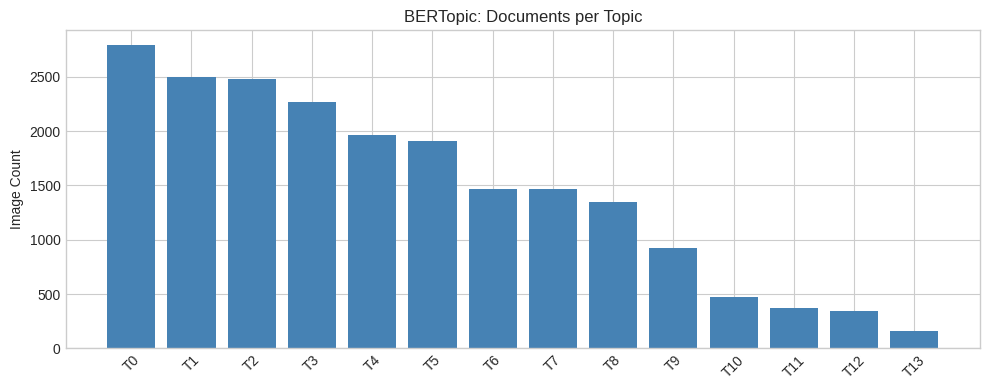

In [7]:
# =========================
# Cell 7 — Inspect discovered topics
# =========================
# Read this output carefully — you'll use it in Cell 8 to define
# the final label taxonomy by merging/renaming topics.

print("=" * 70)
print("BERTOPIC TOPIC SUMMARY")
print("=" * 70)

display(
    topic_info[topic_info["Topic"] != -1]
    [["Topic", "Count", "Name", "Representation"]]
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

print("\nDetailed top keywords per topic:")
for row in topic_info[topic_info["Topic"] != -1].itertuples():
    topic_words = topic_model.get_topic(row.Topic)
    words = [w for w, _ in topic_words[:10]]
    print(f"  Topic {row.Topic:3d}  [{row.Count:5d} docs]  →  {words}")

# Visualize topic sizes
valid = topic_info[topic_info["Topic"] != -1].copy()
plt.figure(figsize=(10, 4))
plt.bar(range(len(valid)), valid["Count"].values, color="steelblue")
plt.xticks(range(len(valid)), [f"T{t}" for t in valid["Topic"].values], rotation=45)
plt.title("BERTopic: Documents per Topic")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

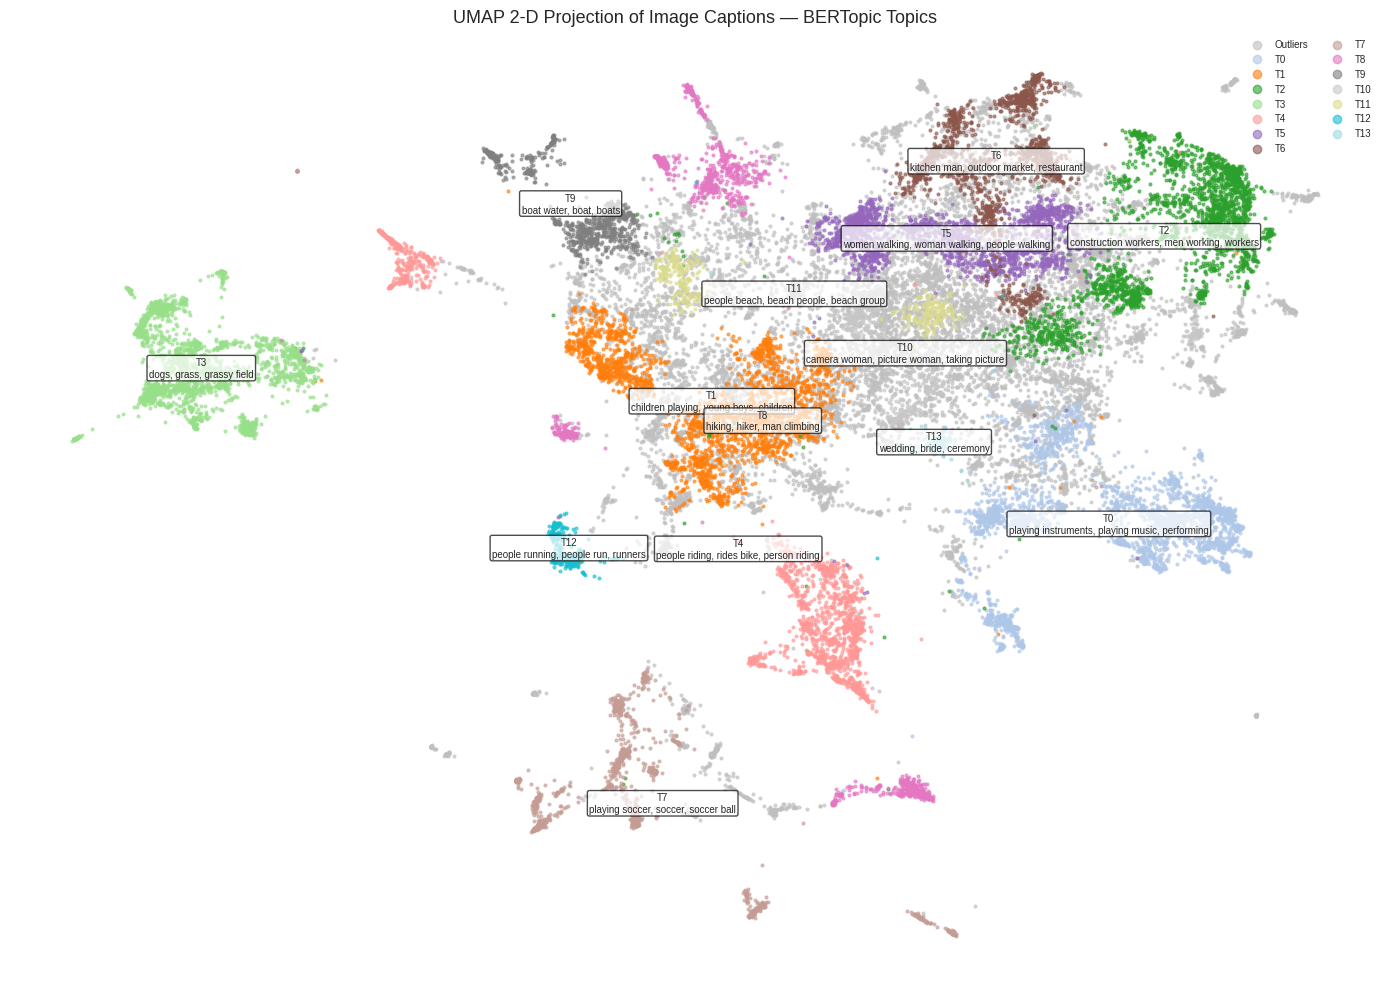

In [8]:
# =========================
# Cell 8 — 2-D UMAP visualization of topics
# =========================
# Scatter plot of all images coloured by topic — useful to spot
# sub-clusters that should be merged or split.

umap_2d = UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)
proj_2d = umap_2d.fit_transform(embeddings)

df_img["umap_x"] = proj_2d[:, 0]
df_img["umap_y"] = proj_2d[:, 1]

# Assign color per topic (grey for outliers)
unique_topics = sorted(df_img["bertopic_id"].unique())
cmap = plt.cm.get_cmap("tab20", len(unique_topics))
color_map = {t: cmap(i) for i, t in enumerate(unique_topics)}
color_map[-1] = (0.75, 0.75, 0.75, 0.3)   # outliers = light grey

plt.figure(figsize=(14, 10))
for tid in unique_topics:
    mask = df_img["bertopic_id"] == tid
    label = f"T{tid}" if tid != -1 else "Outliers"
    plt.scatter(
        df_img.loc[mask, "umap_x"],
        df_img.loc[mask, "umap_y"],
        s=4, alpha=0.6, color=color_map[tid], label=label,
    )

# Annotate cluster centroids
for tid in unique_topics:
    if tid == -1:
        continue
    mask = df_img["bertopic_id"] == tid
    cx = df_img.loc[mask, "umap_x"].mean()
    cy = df_img.loc[mask, "umap_y"].mean()
    top_words = [w for w, _ in topic_model.get_topic(tid)[:3]]
    plt.text(cx, cy, f"T{tid}\n{', '.join(top_words)}", fontsize=7,
             ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

plt.title("UMAP 2-D Projection of Image Captions — BERTopic Topics", fontsize=13)
plt.legend(loc="upper right", fontsize=7, markerscale=3, ncol=2)
plt.axis("off")
plt.tight_layout()
plt.show()

# PHASE 2

In [17]:
# =========================
# Cell 9 — [ACTION REQUIRED] Define label taxonomy from BERTopic results
# =========================

TOPIC_TO_LABEL = {
    # BERTopic ID  →  label name
    0:  "music_performance",     # playing instruments, concert, guitar
    1:  "children",              # children playing, young boys
    2:  "construction_work",     # workers, building, construction site
    3:  "dogs",                  # dogs, grass, walking dog
    4:  "biking",                # riding bikes, bicycles
    5:  "street_walking",        # women walking, walking city, sidewalk
    6:  "food_and_market",       # kitchen, outdoor market, restaurant, vendor
    7:  "sports",                # soccer, players, ball
    8:  "outdoor_adventure",     # hiking, climbing, snow, skating
    9:  "water_boats",           # boat, water, sailing, fishing
    10: "taking_pictures",       # taking pictures, camera
    11: "beach",                 # people beach, sitting beach
    12: "sports",                # running, marathon, race (Merged with Topic 7)
    13: "wedding",               # bride, ceremony, groom
    -1: "other",                 # BERTopic outliers — will be re-labeled by NLI
}

# Final label set (unique non-'other' values from TOPIC_TO_LABEL)
LABEL_NAMES = sorted(set(v for v in TOPIC_TO_LABEL.values() if v != "other"))
print(f"Final label taxonomy ({len(LABEL_NAMES)} classes):")
print(LABEL_NAMES)

# Apply mapping
df_img["label_coarse"] = df_img["bertopic_id"].map(TOPIC_TO_LABEL).fillna("other")

print("\nLabel distribution after BERTopic mapping:")
display(df_img["label_coarse"].value_counts())

Final label taxonomy (13 classes):
['beach', 'biking', 'children', 'construction_work', 'dogs', 'food_and_market', 'music_performance', 'outdoor_adventure', 'sports', 'street_walking', 'taking_pictures', 'water_boats', 'wedding']

Label distribution after BERTopic mapping:


label_coarse
other                11326
music_performance     2790
children              2497
construction_work     2479
dogs                  2265
biking                1969
street_walking        1906
sports                1808
food_and_market       1469
outdoor_adventure     1346
water_boats            921
taking_pictures        475
beach                  374
wedding                158
Name: count, dtype: int64

In [18]:
# =========================
# Cell 10 — Phase 2: Zero-shot NLI for 'other' images + confidence scoring
# =========================
# Images assigned 'other' by BERTopic (outliers) are re-labeled using
# facebook/bart-large-mnli zero-shot classification.
# We also run NLI on ALL images to get a confidence score — this lets
# you filter low-confidence assignments downstream.

ZS_MODEL = "facebook/bart-large-mnli"   # strong MNLI model, ~1.6 GB
# Lightweight alternative: "cross-encoder/nli-MiniLM2-L6-H768" (~100 MB)

print(f"Loading zero-shot classifier: {ZS_MODEL}")
zs_classifier = pipeline(
    "zero-shot-classification",
    model=ZS_MODEL,
    device=0 if __import__('torch').cuda.is_available() else -1,
)
print("Model loaded.")

# Hypothesis template — phrased to match Flickr30k caption style
ZS_HYPOTHESIS = "This image shows {}."

# We run NLI on a representative text per image (first caption is shorter
# and cleaner than the concatenated blob)
df_first = (
    df.groupby("image_id")[caption_col]
    .first()
    .reset_index()
    .rename(columns={caption_col: "caption_first"})
)
df_img = df_img.merge(df_first, on="image_id", how="left")

print(f"Running zero-shot classification on {len(df_img)} images...")
print(f"Label candidates: {LABEL_NAMES}")

Loading zero-shot classifier: facebook/bart-large-mnli


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Model loaded.
Running zero-shot classification on 31783 images...
Label candidates: ['beach', 'biking', 'children', 'construction_work', 'dogs', 'food_and_market', 'music_performance', 'outdoor_adventure', 'sports', 'street_walking', 'taking_pictures', 'water_boats', 'wedding']


In [21]:
# =========================
# Cell 11 — Run zero-shot NLI in batches (Dual GPU + High VRAM)
# =========================
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

# 1. Crank up the batch size to utilize the 15GiB VRAM!
BATCH_SIZE = 256  

texts = df_img["caption_first"].fillna("").tolist()

# 2. Duplicate the pipeline for the second GPU
# (zs_classifier from Cell 10 is already on GPU 0)
print("Loading a second model instance on GPU 1 to double throughput...")
zs_classifier_gpu1 = pipeline(
    "zero-shot-classification",
    model=ZS_MODEL,       # Reuses the model name from Cell 10
    device=1              # Targets the second T4 GPU
)

def process_batch(batch_info):
    batch_texts, gpu_id = batch_info
    
    # Route to the correct GPU model
    classifier = zs_classifier if gpu_id == 0 else zs_classifier_gpu1
    
    # KEY FIX: explicitly passing batch_size forces hardware-level VRAM utilization
    results = classifier(
        batch_texts,
        candidate_labels=LABEL_NAMES,
        hypothesis_template=ZS_HYPOTHESIS,
        multi_label=False,
        batch_size=len(batch_texts)  
    )
    
    if isinstance(results, dict):           
        results = [results]
    return results

# 3. Prepare the batches and assign alternating GPUs
batches = []
for i in range(0, len(texts), BATCH_SIZE):
    batch = texts[i : i + BATCH_SIZE]
    gpu_id = (i // BATCH_SIZE) % 2   # Alternates: 0, 1, 0, 1...
    batches.append((batch, gpu_id))

print(f"Distributing {len(batches)} batches across both T4 GPUs...\n")

all_results = []

# 4. Execute concurrently (ThreadPoolExecutor runs both GPUs at the exact same time)
# 'executor.map' guarantees the output list stays in the exact original order
with ThreadPoolExecutor(max_workers=2) as executor:
    for res in tqdm(executor.map(process_batch, batches), total=len(batches), desc="NLI Batches"):
        all_results.extend(res)

# 5. Extract and format the scores
zs_labels = []
zs_scores = []
zs_all = []

for r in all_results:
    top_label = r["labels"][0]
    top_score = r["scores"][0]
    score_dict = dict(zip(r["labels"], r["scores"]))
    
    zs_labels.append(top_label)
    zs_scores.append(top_score)
    zs_all.append(score_dict)

df_img["zs_label"] = zs_labels
df_img["zs_score"] = zs_scores

# Expand full score vectors as separate columns
score_df = pd.DataFrame(zs_all)
score_df.columns = [f"zs_score_{c}" for c in score_df.columns]
df_img = pd.concat([df_img.reset_index(drop=True), score_df.reset_index(drop=True)], axis=1)

print("\nZero-shot classification complete.")
print("ZS label distribution:")
display(df_img["zs_label"].value_counts())

Loading a second model instance on GPU 1 to double throughput...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Distributing 125 batches across both T4 GPUs...



NLI Batches:   0%|          | 0/125 [00:00<?, ?it/s]


Zero-shot classification complete.
ZS label distribution:


zs_label
children             7145
outdoor_adventure    5705
sports               4593
taking_pictures      3937
dogs                 2145
music_performance    2074
street_walking       1782
construction_work    1476
biking               1133
food_and_market       961
beach                 435
water_boats           272
wedding               125
Name: count, dtype: int64

In [22]:
# =========================
# Cell 12 — Final label fusion: BERTopic + NLI
# =========================
# Strategy:
#   - If BERTopic gave a non-'other' label → use BERTopic label
#     (BERTopic clusters are dense, high-confidence regions)
#   - If BERTopic said 'other' (outlier) → use ZS NLI label
#   - Optionally: use ZS score as a confidence filter
#
# You can swap to a fully NLI-driven assignment by setting
# FUSION_STRATEGY = "nli_only"

FUSION_STRATEGY = "bertopic_first"   # options: 'bertopic_first' | 'nli_only' | 'vote'
ZS_CONFIDENCE_THRESHOLD = 0.30       # images below this are marked 'uncertain'


def fuse_labels(row):
    if FUSION_STRATEGY == "nli_only":
        return row["zs_label"]

    elif FUSION_STRATEGY == "bertopic_first":
        if row["label_coarse"] != "other":
            return row["label_coarse"]
        return row["zs_label"]

    elif FUSION_STRATEGY == "vote":
        # Simple majority: if both agree use that, else prefer NLI
        if row["label_coarse"] == row["zs_label"]:
            return row["label_coarse"]
        if row["label_coarse"] == "other":
            return row["zs_label"]
        # Disagree: trust NLI score
        return row["zs_label"] if row["zs_score"] >= 0.50 else row["label_coarse"]

    return row["zs_label"]


df_img["label_final"] = df_img.apply(fuse_labels, axis=1)

# Flag low-confidence images
df_img["label_uncertain"] = (
    (df_img["label_coarse"] == "other") &
    (df_img["zs_score"] < ZS_CONFIDENCE_THRESHOLD)
)

print(f"Final label distribution (strategy='{FUSION_STRATEGY}'):")
display(df_img["label_final"].value_counts())

print(f"\nUncertain labels (NLI score < {ZS_CONFIDENCE_THRESHOLD}): {df_img['label_uncertain'].sum()}")

Final label distribution (strategy='bertopic_first'):


label_final
children             5816
outdoor_adventure    4114
music_performance    3095
taking_pictures      2844
sports               2790
construction_work    2773
street_walking       2467
dogs                 2310
biking               2047
food_and_market      1802
water_boats           960
beach                 582
wedding               183
Name: count, dtype: int64


Uncertain labels (NLI score < 0.3): 938


Agreement between BERTopic and NLI on non-outlier images: 59.4%


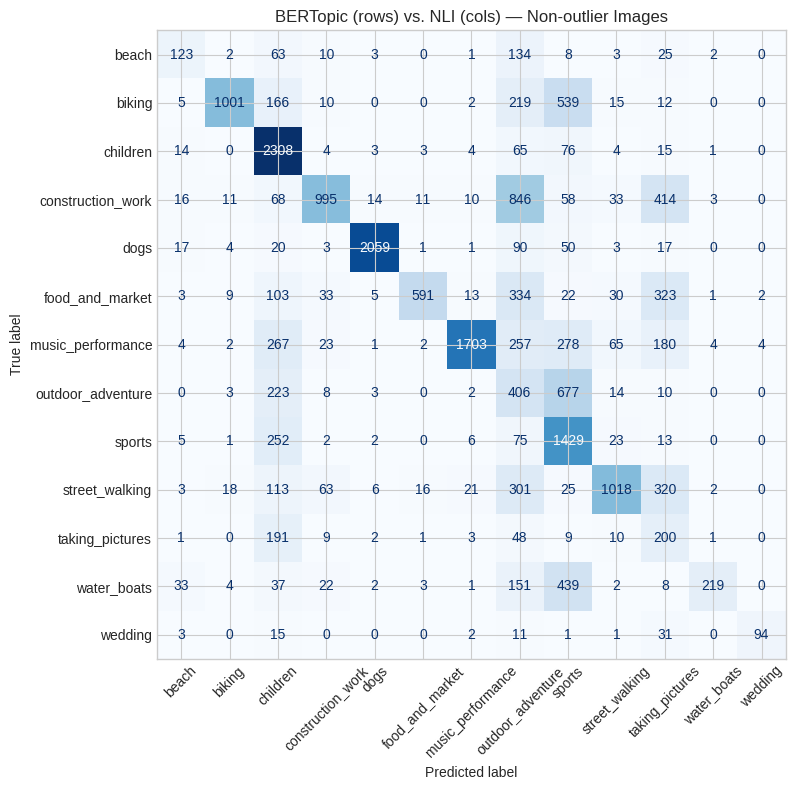

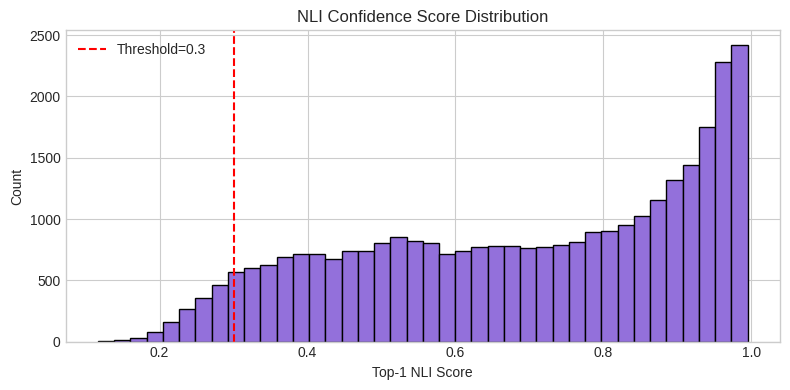

In [24]:
# =========================
# Cell 13 — Diagnostic: agreement between BERTopic and NLI
# =========================

valid_mask = df_img["label_coarse"] != "other"
agree = (df_img.loc[valid_mask, "label_coarse"] == df_img.loc[valid_mask, "zs_label"]).mean()
print(f"Agreement between BERTopic and NLI on non-outlier images: {agree:.1%}")

# Confusion between BERTopic and NLI
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sub = df_img[valid_mask].copy()
all_labels_sorted = sorted(LABEL_NAMES)
cm = confusion_matrix(sub["label_coarse"], sub["zs_label"], labels=all_labels_sorted)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=all_labels_sorted)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
ax.set_title("BERTopic (rows) vs. NLI (cols) — Non-outlier Images", fontsize=12)
plt.tight_layout()
plt.show()

# Score distribution
plt.figure(figsize=(8, 4))
plt.hist(df_img["zs_score"], bins=40, color="mediumpurple", edgecolor="black")
plt.axvline(ZS_CONFIDENCE_THRESHOLD, color="red", linestyle="--",
            label=f"Threshold={ZS_CONFIDENCE_THRESHOLD}")
plt.title("NLI Confidence Score Distribution")
plt.xlabel("Top-1 NLI Score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# =========================
# Cell 14 — Qualitative sanity check: sample images per label
# =========================
# Display 4 sample captions per label so you can visually verify
# the labeling quality.

SAMPLES_PER_LABEL = 4

for label in sorted(df_img["label_final"].unique()):
    sub = df_img[df_img["label_final"] == label]
    sample = sub.sample(min(SAMPLES_PER_LABEL, len(sub)), random_state=42)
    print(f"\n{'='*60}")
    print(f"LABEL: {label.upper()}  ({len(sub)} images)")
    print(f"{'='*60}")
    for _, row in sample.iterrows():
        bert_tag = f"[BERTopic T{row['bertopic_id']}]" if row["bertopic_id"] != -1 else "[outlier]"
        nli_tag  = f"[NLI={row['zs_label']} {row['zs_score']:.2f}]"
        print(f"  {bert_tag} {nli_tag}")
        print(f"  Caption: {row['caption_first'][:120]}")


LABEL: BEACH  (582 images)
  [outlier] [NLI=beach 0.46]
  Caption: Lady in a pink Tinkerbell jacket stands next to the railing and looks out at the water .
  [BERTopic T11] [NLI=outdoor_adventure 0.61]
  Caption: A group of five friends walk along an empty plain with their backs to a small body of water , mountains looming in the d
  [outlier] [NLI=beach 0.47]
  Caption: A group of people on the beach run in the sand away from the water .
  [outlier] [NLI=beach 0.92]
  Caption: A man and a woman all dressed in white at the beach near a palm tree kissing and holding each other .

LABEL: BIKING  (2047 images)
  [BERTopic T4] [NLI=outdoor_adventure 0.58]
  Caption: An older couple pose with a motor scooter , while wearing renaissance festival clothing .
  [BERTopic T4] [NLI=biking 0.44]
  Caption: A kid with a white shirt and helmet riding a bike through the woods
  [BERTopic T4] [NLI=biking 0.66]
  Caption: A large crowd is assembled on an outdoor street scene , with toy balloons visibl

In [26]:
# =========================
# Cell 15 — Build final labeled dataset
# =========================

label_to_id = {label: i for i, label in enumerate(sorted(LABEL_NAMES))}

df_final = df_img[[
    "image_id", "image_path", "image_file",
    "label_final", "label_coarse",
    "zs_label", "zs_score",
    "label_uncertain", "bertopic_id",
    "caption_first", "captions",
]].copy()

df_final["label"]      = df_final["label_final"]
df_final["label_id"]   = df_final["label"].map(label_to_id)

# Also attach soft-label score columns for few-shot or soft-CE training
soft_cols = [c for c in df_img.columns if c.startswith("zs_score_")]
df_final = pd.concat([df_final, df_img[soft_cols]], axis=1)

print("Final dataset shape:", df_final.shape)
print("\nLabel distribution:")
display(df_final["label"].value_counts())

print("\nSample rows:")
display(df_final[["image_id", "label", "label_id", "zs_score", "label_uncertain"]].head(8))

Final dataset shape: (31783, 63)

Label distribution:


label
children             5816
outdoor_adventure    4114
music_performance    3095
taking_pictures      2844
sports               2790
construction_work    2773
street_walking       2467
dogs                 2310
biking               2047
food_and_market      1802
water_boats           960
beach                 582
wedding               183
Name: count, dtype: int64


Sample rows:


,image_id,label,label_id,zs_score,label_uncertain
0,1000092795,construction_work,3,0.672723,False
1,10002456,construction_work,3,0.719118,False
2,1000268201,children,2,0.981141,False
3,1000344755,construction_work,3,0.479933,False
4,1000366164,food_and_market,5,0.599087,False
5,1000523639,music_performance,6,0.940139,False
6,1000919630,outdoor_adventure,7,0.455932,False
7,10010052,outdoor_adventure,7,0.829082,False


In [27]:
# =========================
# Cell 16 — Save outputs
# =========================

# 1. Full labeled CSV
out_csv = os.path.join(WORKING_DIR, "flickr30k_labeled_bertopic.csv")
df_final.to_csv(out_csv, index=False)
print("Saved labeled CSV:", out_csv)

# 2. High-confidence only (recommended for training)
df_confident = df_final[~df_final["label_uncertain"]]
out_conf_csv = os.path.join(WORKING_DIR, "flickr30k_labeled_confident.csv")
df_confident.to_csv(out_conf_csv, index=False)
print(f"Saved high-confidence CSV ({len(df_confident)} images):", out_conf_csv)

# 3. Label mapping JSON
out_map = os.path.join(WORKING_DIR, "flickr30k_label_mapping.json")
with open(out_map, "w") as f:
    json.dump({"label_to_id": label_to_id, "label_names": LABEL_NAMES}, f, indent=2)
print("Saved label mapping:", out_map)

# 4. BERTopic model (for reproducibility / topic inference on new data)
out_topic_model = os.path.join(WORKING_DIR, "bertopic_model")
topic_model.save(out_topic_model, serialization="safetensors", save_ctfidf=True)
print("Saved BERTopic model:", out_topic_model)

# 5. Topic taxonomy summary
topic_summary = []
for row in topic_info[topic_info["Topic"] != -1].itertuples():
    words = [w for w, _ in topic_model.get_topic(row.Topic)[:10]]
    mapped_label = TOPIC_TO_LABEL.get(row.Topic, "other")
    topic_summary.append({
        "topic_id": row.Topic,
        "doc_count": row.Count,
        "mapped_label": mapped_label,
        "top_words": words,
    })

out_topics = os.path.join(WORKING_DIR, "topic_taxonomy.json")
with open(out_topics, "w") as f:
    json.dump(topic_summary, f, indent=2)
print("Saved topic taxonomy:", out_topics)

print("\nAll outputs saved to:", WORKING_DIR)

Saved labeled CSV: /kaggle/working/flickr30k_labeled_bertopic.csv
Saved high-confidence CSV (30845 images): /kaggle/working/flickr30k_labeled_confident.csv
Saved label mapping: /kaggle/working/flickr30k_label_mapping.json
Saved BERTopic model: /kaggle/working/bertopic_model
Saved topic taxonomy: /kaggle/working/topic_taxonomy.json

All outputs saved to: /kaggle/working


## Summary

| Step | Method | Role |
|------|--------|------|
| 1 | `SentenceTransformer` (`all-MiniLM-L6-v2`) | Dense caption embeddings |
| 2 | `UMAP` (5-D) + `HDBSCAN` | Cluster similar images together |
| 3 | `BERTopic` + `KeyBERTInspired` | Discover & name semantic topics |
| 4 | Manual taxonomy mapping | Merge topics → final label set |
| 5 | `facebook/bart-large-mnli` | Zero-shot NLI for outliers + confidence |
| 6 | Fusion | BERTopic-first assignment, NLI fallback |

### Output files
- `flickr30k_labeled_bertopic.csv` — all images with labels
- `flickr30k_labeled_confident.csv` — filtered high-confidence subset
- `flickr30k_label_mapping.json` — `{label_to_id, label_names}`
- `bertopic_model/` — saved BERTopic model (can label new images)
- `topic_taxonomy.json` — audit trail: which BERTopic topics → which labels

### Next steps
- Feed `flickr30k_labeled_confident.csv` into your zero-shot / few-shot classification experiments
- Use `zs_score_*` columns as soft labels for knowledge distillation
- Load `bertopic_model/` to assign labels to any new unseen images